## Code

  Abhishek V Ammanagi  |  2023BCSE07AED500
  Experiment 1: Face Recognition Attendance


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 2,388,485 (9.11 MB)

 Non-trainable params: 34,112 (133.25 KB)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 37s 542ms/step - accuracy: 0.1800 - loss: 1.9854 - val_accuracy: 0.2400 - val_loss: 1.6083
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 389ms/step - accuracy: 0.3850 - loss: 1.4797 - val_accuracy: 0.2600 - val_loss: 1.6088
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 396ms/step - accuracy: 0.5850 - loss: 1.0502 - val_accuracy: 0.2400 - val_loss: 1.6069
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 394ms/step - accuracy: 0.6500 - loss: 1.0297 - val_accuracy: 0.1400 - val_loss: 1.6088
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 402ms/step - accuracy: 0.6200 - loss: 1.1121 - val_accuracy: 0.1400 - val_loss: 1.6088
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 391ms/step - accuracy: 0.5850 - loss: 1.0204 - val_accuracy: 0.1400 - val_loss: 1.6099
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 388ms/step - accuracy: 0.7500 - loss: 0.7956 - val_accuracy: 0.2400 - val_loss: 1.6065
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 390ms/step - accuracy: 0.7600 - loss: 0.6700 - val_accuracy: 0

c:\Users\manju\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\manju\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\manju\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


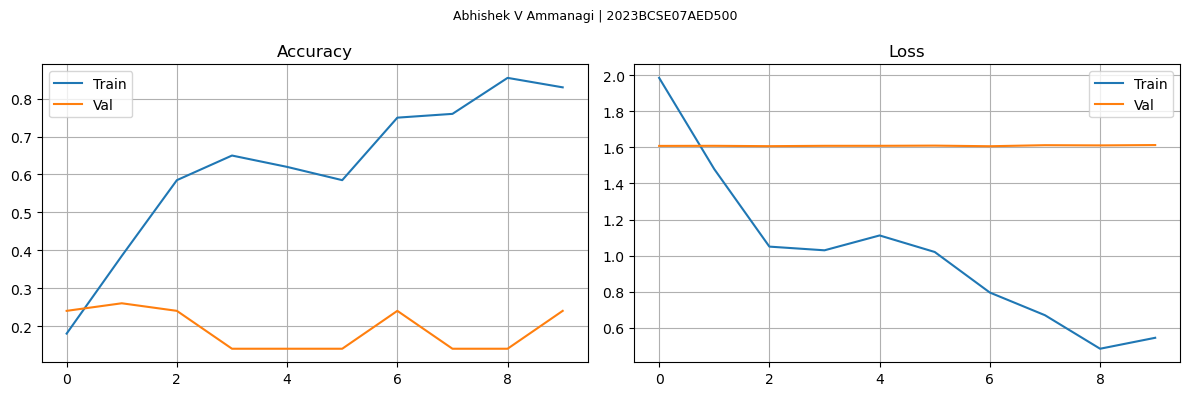

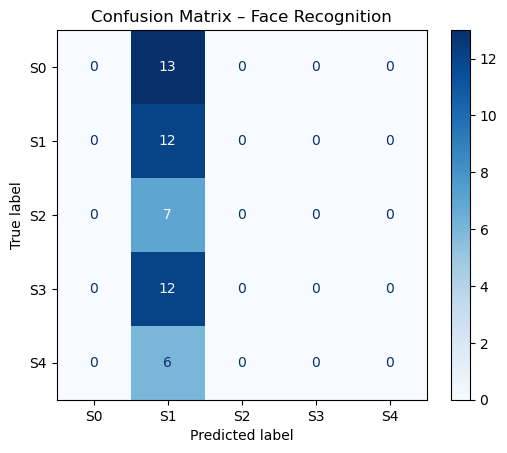

Attendance marked. Abhishek V Ammanagi | 2023BCSE07AED500


In [1]:
# Experiment 1 – Face Recognition Attendance
# Abhishek V Ammanagi | 2023BCSE07AED500

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("=" * 55)
print("  Abhishek V Ammanagi  |  2023BCSE07AED500")
print("  Experiment 1: Face Recognition Attendance")
print("=" * 55)

IMG_SIZE    = 160
NUM_CLASSES = 5       # 5 students
BATCH_SIZE  = 16
EPOCHS      = 10
np.random.seed(42)

# Synthetic dataset – replace with real face images
X_train = np.random.rand(200, IMG_SIZE, IMG_SIZE, 3).astype("float32")
y_train = np.random.randint(0, NUM_CLASSES, 200)
X_val   = np.random.rand(50,  IMG_SIZE, IMG_SIZE, 3).astype("float32")
y_val   = np.random.randint(0, NUM_CLASSES, 50)

y_tr_cat = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_va_cat = tf.keras.utils.to_categorical(y_val,   NUM_CLASSES)

# Build model
base = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                   include_top=False, weights=None)
base.trainable = True

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

history = model.fit(X_train, y_tr_cat,
                    validation_data=(X_val, y_va_cat),
                    epochs=EPOCHS, batch_size=BATCH_SIZE)

loss, acc = model.evaluate(X_val, y_va_cat, verbose=0)
y_pred    = np.argmax(model.predict(X_val), axis=1)

print(f"\nValidation Accuracy : {acc:.4f}")
print(f"Validation Loss     : {loss:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred,
      target_names=[f"Student_{i}" for i in range(NUM_CLASSES)]))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['accuracy'],     label='Train')
ax[0].plot(history.history['val_accuracy'], label='Val')
ax[0].set_title('Accuracy'); ax[0].legend(); ax[0].grid(True)
ax[1].plot(history.history['loss'],     label='Train')
ax[1].plot(history.history['val_loss'], label='Val')
ax[1].set_title('Loss'); ax[1].legend(); ax[1].grid(True)
plt.suptitle("Abhishek V Ammanagi | 2023BCSE07AED500", fontsize=9)
plt.tight_layout(); plt.savefig('exp1_face.png', dpi=300); plt.show()

cm   = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(cm,
       display_labels=[f"S{i}" for i in range(NUM_CLASSES)])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix – Face Recognition")
plt.savefig('exp1_cm.png', dpi=300); plt.show()

print("Attendance marked. Abhishek V Ammanagi | 2023BCSE07AED500")


## Result
_Run the cell above and paste your observations here._